In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format}) 
import statsmodels.api as sm
#this option makes Jupyter print numbers in ordinary (as opposed to scientific) notation

# Bayesian approaches to Poisson Regression

Let us revisit the following dataset that we previously analyzed in Lab 7. This dataset (called MROZ) comes from an Econometrica paper by Mroz in 1987 and contains data on a bunch of variables for married women in the year 1975. This dataset is analyzed in the Econometrics book by Wooldridge (this book contains many other interesting economic and political datasets). The specific variables included in the Mroz dataset are: 

1. inlf: binary variable equaling 1 if the individual worked (i.e., they were 'in the labor force') in the year 1975 and 0 otherwise
2. hours: number of hours worked in 1975
3. kidslt6: number of kids < 6 years of age
4. kidsge6: number of kids 6-18 years of age
5. age: age in years
6. educ: years of schooling
7. wage: hourly wage in 1975
8. repwage: reported wage at interview in 1976
9. hushrs: hours worked by husband in 1975
10. husage: husband's age
11. huseduc: husband's years of schooling
12. huswage: husband's hourly wage in 1975
13. faminc: family income in 1975
14. mtr: federal marginal tax rate facing woman
15. motheduc: mother's years of schooling
16. fatheduc: father's years of schooling
17. unem: unemployment rate in county of residence
18. city: =1 if live in Standard metropolitan statistical area
19. exper: actual labor market experience
20. nwifeinc: (faminc - wage*hours)/1000
21. lwage: log(wage)
22. expersq: $\text{exper}^2$ (the square of the experience variable)

In [4]:
#Import the MROZ.csv dataset
mroz = pd.read_csv("MROZ.csv")
print(mroz.head(12))

    inlf  hours  kidslt6  kidsge6  age  educ    wage  repwage  hushrs  husage  \
0      1   1610        1        0   32    12  3.3540     2.65    2708      34   
1      1   1656        0        2   30    12  1.3889     2.65    2310      30   
2      1   1980        1        3   35    12  4.5455     4.04    3072      40   
3      1    456        0        3   34    12  1.0965     3.25    1920      53   
4      1   1568        1        2   31    14  4.5918     3.60    2000      32   
5      1   2032        0        0   54    12  4.7421     4.70    1040      57   
6      1   1440        0        2   37    16  8.3333     5.95    2670      37   
7      1   1020        0        0   54    12  7.8431     9.98    4120      53   
8      1   1458        0        2   48    12  2.1262     0.00    1995      52   
9      1   1600        0        2   39    12  4.6875     4.15    2100      43   
10     1   1969        0        1   33    12  4.0630     4.30    2450      34   
11     1   1960        0    

In Lab 7, we fit the Poisson regression model to this dataset, using "hours" as the response variable, and "kidslt6", "kidsge6", "age", "educ", "exper", "expersq", "huswage", "huseduc", "hushrs", "motheduc" and "fatheduc" as the covariates (or predictor variables).

The Poisson regression model is given by: 
\begin{align*}
   &Y_i \sim \text{Poisson}(\mu_i) ~~ \text{ for } i = 1, \dots, n \\
   &\log \mu_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_m x_{im} ~~ \text{ for } i = 1, \dots, n 
\end{align*}
Here $Y_i$ is the number of hours worked in 1975 which is a count variable, so Poisson regression is appropriate here. The linear relationship between the response and covariates is specified through $\log \mu_i$ which enables percentage interpretation for the regression coefficients. 

The standard way of fitting the Poisson regression model is to use the inbuilt statsmodels function **sm.GLM**. GLM stands for Generalized Linear Models which is a general class of models which includes linear regression and Poisson regression (and also logistic regression). While using sm.GLM, we need to specify which GLM we are fitting using the **family** argument. 

In [5]:
#Poisson Regression through StatsModels
# Define the response variable and covariates
Y = mroz['hours']
X = mroz[['kidslt6', 'age', 'educ', 
        'huswage', 'exper', 'expersq']].copy()
X = sm.add_constant(X) # Add a constant (intercept) to the model
# Fit the Poisson regression model
poiregmodel = sm.GLM(Y, X, family=sm.families.Poisson()).fit()
print(poiregmodel.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  hours   No. Observations:                  753
Model:                            GLM   Df Residuals:                      746
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.1563e+05
Date:                Sat, 04 Apr 2026   Deviance:                   6.2754e+05
Time:                        11:24:06   Pearson chi2:                 6.60e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9365      0.012    562.281      0.0

The output above looks very similar to a linear regression output. The fitted coefficients can be nicely interpreted. For example, the coefficient -0.8075 for the "kidslt6" variable means that having a small kid reduces mean hours worked by 55%. This 55\% comes from the following calculation: 

In [6]:
#56% comes from:
print((np.exp(poiregmodel.params['kidslt6']) - 1)*100)

-55.40391074218092


The regression coefficients above are obtained by the method of Maximum Likelihood. The likelihood in this Poisson Regression Model is given by
\begin{align*}
  \text{likelihood} &= \prod_{i=1}^n \frac{e^{-\mu_i} \mu_i^{y_i}}{y_i!} = \prod_{i=1}^n \frac{e^{-e^{\beta_0 + \beta_1 x_{i1} + \dots + \beta_m x_{im}}} e^{y_i(\beta_0 + \beta_1 x_{i1} + \dots + \beta_m x_{im})}}{y_i!} 
\end{align*}
so the log-likelihood is (ignoring constant terms): 
\begin{align*}
    \ell(\beta) = \sum_{i=1}^n \left(-e^{x_i^T \beta} + y_i x_i^T \beta \right)
\end{align*}
This is maximized by Newton's method which uses the gradient and Hessian of the log-likelihood: 
\begin{align*}
   \beta^{(m+1)} = \beta^{(m)} - (H\ell(\beta^{(m)}))^{-1} \nabla \ell(\beta^{(m)}),
\end{align*}
The gradient is 
\begin{align*}
   \nabla \ell(\beta) = \sum_{i=1}^n \left(-e^{x_i^T \beta} x_i + y_i x_i \right) = \sum_{i=1}^n \left(y_i - e^{x_i^T \beta} \right) x_i =  \sum_{i=1}^n \left(y_i - \mu_i \right) x_i = X^T(Y - \mu).
\end{align*}
where $\mu$ is the $n \times 1$ vector with entries $\mu_1 = e^{x_1^T \beta}, \dots, \mu_n = e^{x_n^T \beta}$, and the Hessian is:
\begin{align*}
   H \ell(\beta) = - \sum_{i=1}^n e^{x_i^T \beta} x_i x_i^T = - \sum_{i=1}^n \mu_i x_i x_i^T.
\end{align*}
We can rewrite this in matrix form as 
\begin{align*}
   H \ell(\beta) = - X^T M(\beta) X 
\end{align*}
where $M(\beta)$ is the diagonal matrix with diagonal entries $\mu_1 = e^{x_1^T \beta}, \dots, \mu_n = e^{x_n^T \beta}$. Thus Newton's method for Poisson regression is:
\begin{align*}
  \beta^{(m+1)} = \beta^{(m)} + \left(X^T M(\beta^{(m)}) X \right)^{-1} \left( X^T Y - X^T \mu(\beta^{(m)}) \right), 
\end{align*}
where we wrote $\mu(\beta^{(m)})$ to emphasize that this vector $\mu$ is calculated as $e^{x_1^T \beta}, \dots, e^{x_n^T \beta}$ with $\beta = \beta^{(m)}$. 

sm.GLM uses this method to give estimates of the coefficients. It is very easy to code this up yourselves as we saw in Lab 7. 

The standard errors reported by sm.GLM are computed as the square-roots of the diagonal entries of the matrix: 
\begin{align*}
   \left(-H\ell(\hat{\beta}) \right)^{-1} = \left(X^T M(\hat{\beta}) X \right)^{-1}
\end{align*}
where $\hat{\beta}$ is the MLE and $M(\beta)$ is the diagonal matrix with diagonal entries $\mu_1 = e^{x_1^T \beta}, \dots, \mu_n = e^{x_n^T \beta}$. The validity of these standard errors is commonly justified by frequentist asymptotics. However, they can also be justified from a Bayesian perspective using the Laplace posterior normal approximation. This was illustrated in Lab 7. 

## Bayesian Analysis with Flat Prior

Let us again revisit Bayesian analysis for Poisson regression, and let us work with the uniform prior for $\beta$. This leads to posterior being proportional to the likelihood: 
\begin{align*}
   \text{Prior} = 1  ~~~ \text{ and } ~~~ \text{Likelihood} = \prod_{i=1}^n \frac{e^{-e^{\beta_0 + \beta_1 x_{i1} + \dots + \beta_m x_{im}}} e^{y_i(\beta_0 + \beta_1 x_{i1} + \dots + \beta_m x_{im})}}{y_i!} \propto \exp(\ell(\beta)).
\end{align*}
The posterior is therefore given by
\begin{align*}
   \text{Posterior}(\beta) \propto \exp \left(\ell(\beta) \right) = \exp \left(\sum_{i=1}^n \left(-e^{x_i^T \beta} + y_i x_i^T \beta \right) \right)
\end{align*}
This posterior in $\beta_0, \dots, \beta_m$ cannot be written in terms of standard distributions. 

One can attempt to use PyMC to generate samples from this posterior. PyMC displays some strange behaviour. With randomseed = 0, it gives results that are basically the same as the frequentist analysis. But with randomseed = 4, things do not work. 

In [89]:
initvals = dict(zip(["b0","b1","b2","b3","b4","b5","b6"], poiregmodel.params))

mrozpoimod = pm.Model()
with mrozpoimod:
    # Priors for the unknown model parameters
    b0 = pm.Flat("b0")
    b1 = pm.Flat("b1")
    b2 = pm.Flat("b2")
    b3 = pm.Flat("b3")
    b4 = pm.Flat("b4")
    b5 = pm.Flat("b5")
    b6 = pm.Flat("b6")
    log_mu = b0 + b1 * mroz['kidslt6'] +   b2 * mroz['age'] + b3 * mroz['educ'] + b4 * mroz['huswage'] + b5 * mroz['exper'] + b6 * mroz['expersq']
    # Likelihood
    Y_obs = pm.Poisson("Y_obs", mu=np.exp(log_mu), observed=mroz['hours'])
    idata = pm.sample(4000, chains = 1, random_seed = 0, return_inferencedata = True, initvals = initvals)  
    #idata = pm.sample(4000, chains = 1, random_seed = 4, return_inferencedata = True, initvals = initvals)  #this does not work

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [b0, b1, b2, b3, b4, b5, b6]


/Users/aditya/mambaforge/envs/stat238spring2026/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 1_000 tune and 4_000 draw iterations (1_000 + 4_000 draws total) took 28 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [91]:
b0_samples = idata.posterior['b0'].values.flatten()
b1_samples = idata.posterior['b1'].values.flatten()
b2_samples = idata.posterior['b2'].values.flatten()
b3_samples = idata.posterior['b3'].values.flatten()
b4_samples = idata.posterior['b4'].values.flatten()
b5_samples = idata.posterior['b5'].values.flatten()
b6_samples = idata.posterior['b6'].values.flatten()

allsamples = [b0_samples, b1_samples, b2_samples, b3_samples, b4_samples, b5_samples, b6_samples]
names = ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6']
print("Parameter | Estimate | Std. Dev. | Frequentist | Std. Error")
print("------------|----------|----------")
for i, (name, arr) in enumerate(zip(names, allsamples)):
    print(f"{name:8}| {np.mean(arr):.6f} | {np.std(arr):.6f}  | {poiregmodel.params.values[i]:.6f}  | {poiregmodel.bse.values[i]:.6f}")
#These results seem different from the frequentist output.
#PyMC is also not very reliable here. Change the random seed from 0 to 4
#and look at the results. 

Parameter | Estimate | Std. Dev. | Frequentist | Std. Error
------------|----------|----------
b0      | 6.936672 | 0.012513  | 6.936480  | 0.012336
b1      | -0.807607 | 0.004120  | -0.807524  | 0.004179
b2      | -0.042680 | 0.000211  | -0.042680  | 0.000212
b3      | 0.052822 | 0.000639  | 0.052831  | 0.000633
b4      | -0.020707 | 0.000371  | -0.020714  | 0.000380
b5      | 0.120350 | 0.000552  | 0.120372  | 0.000549
b6      | -0.001828 | 0.000016  | -0.001829  | 0.000016


Below we plot the trace plots i.e., the plot of each coefficient with time: $b_j^{(t)}$ against $t$. 

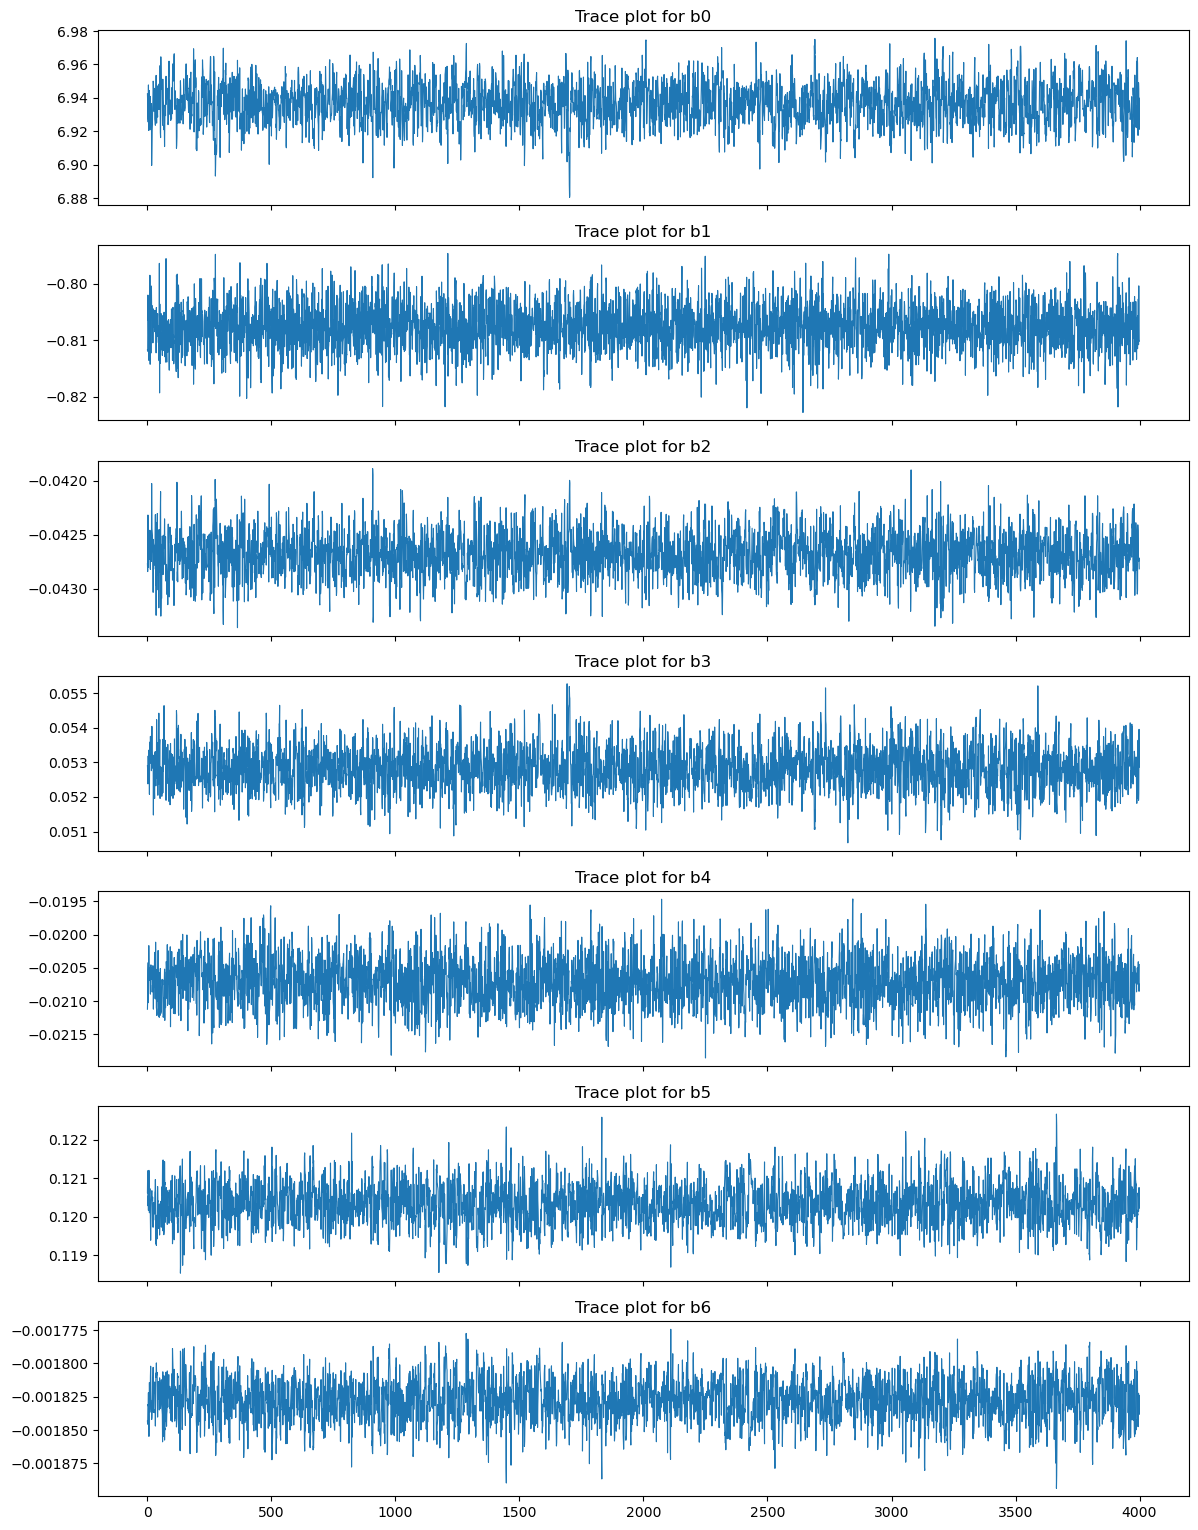

In [92]:
fig, axes = plt.subplots(len(allsamples), 1, figsize=(12, 2.2 * len(allsamples)), sharex=True)

for ax, arr, name in zip(axes, allsamples, names):
    ax.plot(arr, lw=0.8)
    ax.set_title(f"Trace plot for {name}")

plt.tight_layout()
plt.show()

With randomseed = 4, the chain does not move at all for some reason. 

## Metropolis-Hastings

We now apply the Metropolis-Hastings algorithm. The log-likelihood, log-prior and log-posterior functions are given below. 

In [93]:
#Log-likelihood: 
Xm = X.values.astype(float)
y = Y.values.astype(float)

def loglik(th):
    """Poisson log-likelihood (dropping the constant log(y!) term)."""
    eta = Xm @ th
    return np.sum(y * eta - np.exp(eta))

def logprior(th):
    """Flat (uniform) prior => log-prior = 0."""
    return 0.0

def logpost(th):
    """Unnormalized log-posterior = log-likelihood + log-prior."""
    return loglik(th) + logprior(th)



Metropolis-Hastings uses a proposal and then an acceptance-rejection step. For the proposal, the most common choice is that of a random-walk i.e., we take: 
\begin{align*}
   \text{proposed value for } \theta^{(t+1)} = \theta^{(t)} + Z
\end{align*}
where $Z \sim N(0, \Sigma)$. The choice of $\Sigma$ is crucial for the working of the algorithm. The simplest thing is to take $\Sigma = \sigma^2 I$ for some $\sigma$. But the different variables are on different scales, so using one common $\sigma$ might not work. A natural thing to do is to use the covariance matrix corresponding to the Laplace posterior normal approximation. This can actually be obtained from the sm.GLM output, as shown below.

In [ ]:
beta_hat = poiregmodel.params.values
p_dim = len(beta_hat)
cov_mat = poiregmodel.cov_params().values #this is the covariance matrix corresponding to the Laplace posterior normal approximation. It naturally gives us a sense of the scale of the posterior distribution, and is often a good choice for the proposal distribution covariance in a random walk Metropolis algorithm.


0.002615160790187325


Because of the symmetry of the random walk proposal, the acceptance probability in Metropolis-Hastings is simply $\min(\pi(y)/\pi(x), 1)$ (where $\pi(y)$ is the target density at the proposed $y$ and $\pi(x)$ is the target density at the current $x$). 

The code for implementing the Metropolis-Hastings algorithm is given below. 

In [137]:
from scipy.stats import multivariate_normal
nit = 200000
path_rw = np.zeros((nit, p_dim))

#state = beta_hat.copy()
state = np.zeros(p_dim) #we are initializing at zero here. 
#If, instead, we initialize at the MLE, we will get faster mixing. 
path_rw[0, :] = state

rej_rw = 0

for it in range(1, nit):
    # Symmetric proposal centred at the current state
    cand = multivariate_normal.rvs(mean=state, cov=cov_mat)
    #cand = multivariate_normal.rvs(mean=state, cov=np.diag(cov_mat))
    #sig = 0.002 #using a single sigma for all parameters. 
    #cand = state + np.random.normal(0, sig, size=p_dim)
    # Because the proposal is symmetric, acceptance ratio is just
    # the posterior ratio — no Hastings correction needed
    log_ratio = logpost(cand) - logpost(state)

    rnum = np.random.uniform()
    if rnum < np.exp(min(0.0, log_ratio)):
        state = cand
    else:
        rej_rw += 1

    path_rw[it, :] = state

    if (it + 1) % 20000 == 0:
        print(f"Iteration {it + 1}")

print(f"\nRandom walk rejection rate: {rej_rw / nit:.4f}")

Iteration 20000
Iteration 40000
Iteration 60000
Iteration 80000
Iteration 100000
Iteration 120000
Iteration 140000
Iteration 160000
Iteration 180000
Iteration 200000

Random walk rejection rate: 0.7549


Below are the trace plots corresponding to each variable. 

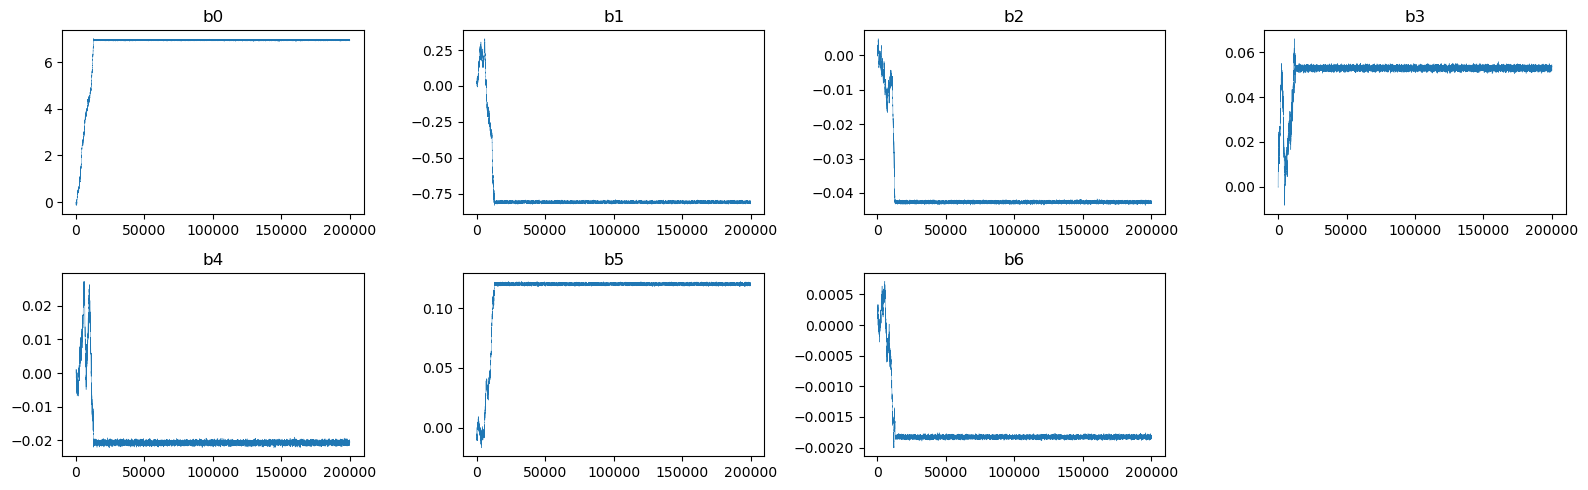

In [138]:
col_names = [f'b{j}' for j in range(p_dim)]
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for j in range(p_dim):
    axes.flat[j].plot(path_rw[:, j], linewidth=0.3)
    axes.flat[j].set_title(col_names[j])
axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()


Clearly the chain is taking some time to mix. We can use a burnin to discard the initial few samples generated by the Markov chain.  

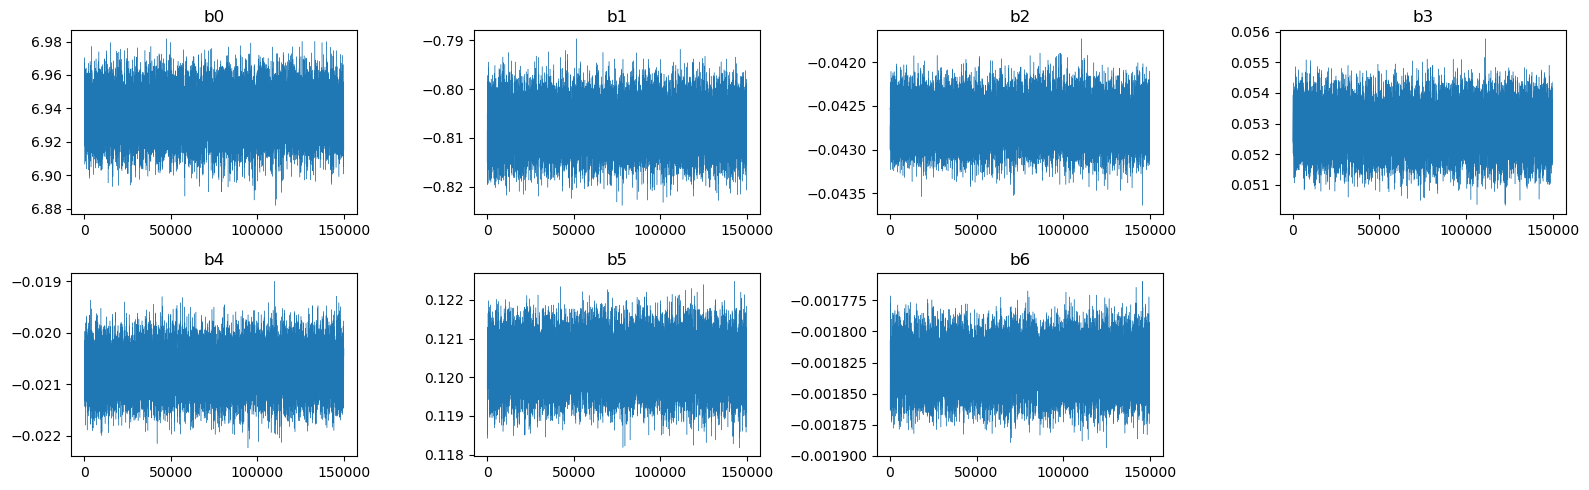

In [139]:
burnin = 50000
samples = path_rw[burnin:, :]
col_names = [f'b{j}' for j in range(p_dim)]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for j in range(p_dim):
    axes.flat[j].plot(samples[:, j], linewidth=0.3)
    axes.flat[j].set_title(col_names[j])
axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()


In [140]:


print("Parameter | Estimate | Std. Dev. | Frequentist | Std. Error")
print("----------|----------|-----------|-------------|----------")
for j in range(p_dim):
    print(f"{col_names[j]:8}| {samples[:, j].mean():.6f} | {samples[:, j].std():.6f}  | {poiregmodel.params.values[j]:.6f}  | {poiregmodel.bse.values[j]:.6f}")



Parameter | Estimate | Std. Dev. | Frequentist | Std. Error
----------|----------|-----------|-------------|----------
b0      | 6.936279 | 0.012251  | 6.936480  | 0.012336
b1      | -0.807442 | 0.004192  | -0.807524  | 0.004179
b2      | -0.042674 | 0.000213  | -0.042680  | 0.000212
b3      | 0.052835 | 0.000632  | 0.052831  | 0.000633
b4      | -0.020722 | 0.000374  | -0.020714  | 0.000380
b5      | 0.120364 | 0.000544  | 0.120372  | 0.000549
b6      | -0.001828 | 0.000016  | -0.001829  | 0.000016


The posterior means and standard deviations are very close those given by the Laplace posterior normal approximation (which is same as frequentist output). Below let us use some alternative choices of the proposal density in Metropolis-Hastings. First, let us try $\Sigma = \sigma^2 I$ (i.e., we are using the same scale for all the variables). 

In [152]:
from scipy.stats import multivariate_normal
nit = 200000
path_rw = np.zeros((nit, p_dim))

#state = beta_hat.copy()
state = np.zeros(p_dim) #we are initializing at zero here. 
#If, instead, we initialize at the MLE, we will get faster mixing. 
path_rw[0, :] = state

rej_rw = 0

for it in range(1, nit):
    # Symmetric proposal centred at the current state
    #cand = multivariate_normal.rvs(mean=state, cov=cov_mat)
    sig = 0.002 #using a single sigma for all parameters. 
    #sig = 0.02
    cand = state + np.random.normal(0, sig, size=p_dim)
    log_ratio = logpost(cand) - logpost(state)

    rnum = np.random.uniform()
    if rnum < np.exp(min(0.0, log_ratio)):
        state = cand
    else:
        rej_rw += 1

    path_rw[it, :] = state

    if (it + 1) % 20000 == 0:
        print(f"Iteration {it + 1}")

print(f"\nRandom walk rejection rate: {rej_rw / nit:.4f}")

Iteration 20000
Iteration 40000
Iteration 60000
Iteration 80000
Iteration 100000
Iteration 120000
Iteration 140000
Iteration 160000
Iteration 180000
Iteration 200000

Random walk rejection rate: 0.9968


Here are the trace plots. 

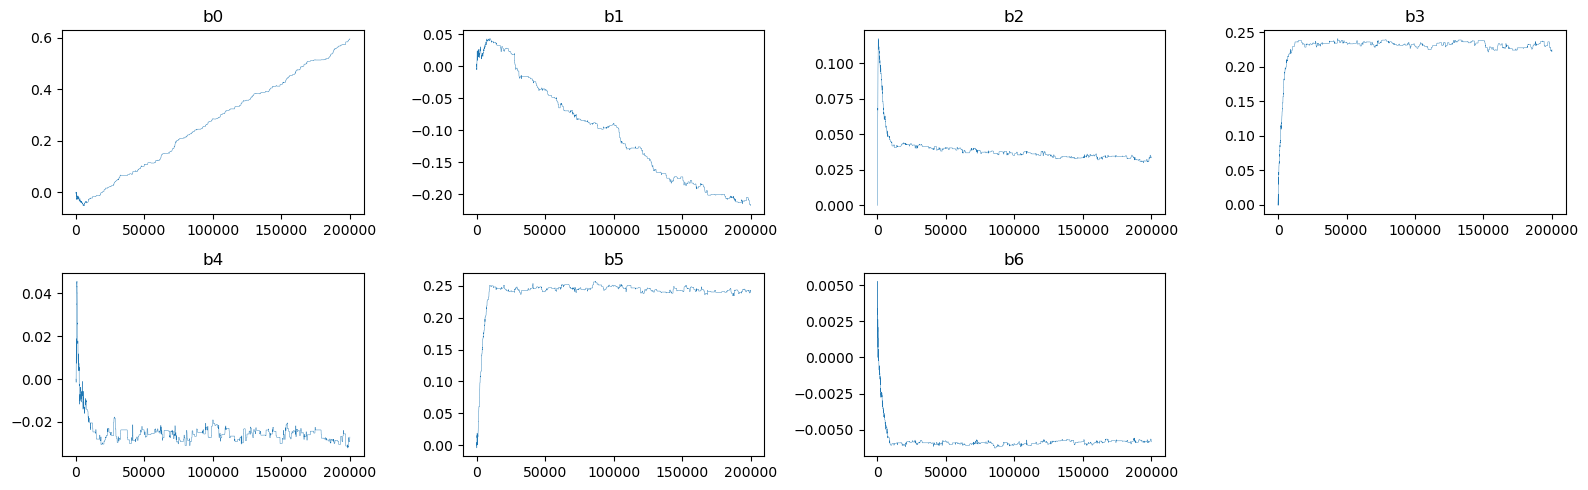

In [153]:
col_names = [f'b{j}' for j in range(p_dim)]
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for j in range(p_dim):
    axes.flat[j].plot(path_rw[:, j], linewidth=0.3)
    axes.flat[j].set_title(col_names[j])
axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()


Clearly this chain has not mixed well. For example, for $b0$, the chain still seems to be continuing to increase after 200K time points (this is not surprising as the frequentist estimate of $b0$ is around 7). We used $\sigma = 0.002$ above, if we increase $\sigma$ to say $0.02$, then the chain has very high rejection rate. 

Next let us use as proposal $N(0, \text{diag}(\Sigma))$ where $\Sigma$ is the covariance of the posterior normal approximation. This makes the proposal indepedent (across variables) but uses the proper scales for each individual variable. 

In [148]:
from scipy.stats import multivariate_normal
nit = 200000
path_rw = np.zeros((nit, p_dim))

#state = beta_hat.copy()
state = np.zeros(p_dim) #we are initializing at zero here. 
#If, instead, we initialize at the MLE, we will get faster mixing. 
path_rw[0, :] = state

rej_rw = 0

for it in range(1, nit):
    # Symmetric proposal centred at the current state
    cand = multivariate_normal.rvs(mean=state, cov=np.diag(cov_mat)) #note we are taking the diagonal part now, which corresponds to independent proposals for each parameter.
    log_ratio = logpost(cand) - logpost(state)

    rnum = np.random.uniform()
    if rnum < np.exp(min(0.0, log_ratio)):
        state = cand
    else:
        rej_rw += 1

    path_rw[it, :] = state

    if (it + 1) % 20000 == 0:
        print(f"Iteration {it + 1}")

print(f"\nRandom walk rejection rate: {rej_rw / nit:.4f}")

Iteration 20000
Iteration 40000
Iteration 60000
Iteration 80000
Iteration 100000
Iteration 120000
Iteration 140000
Iteration 160000
Iteration 180000
Iteration 200000

Random walk rejection rate: 0.9792


Below are the trace plots. 

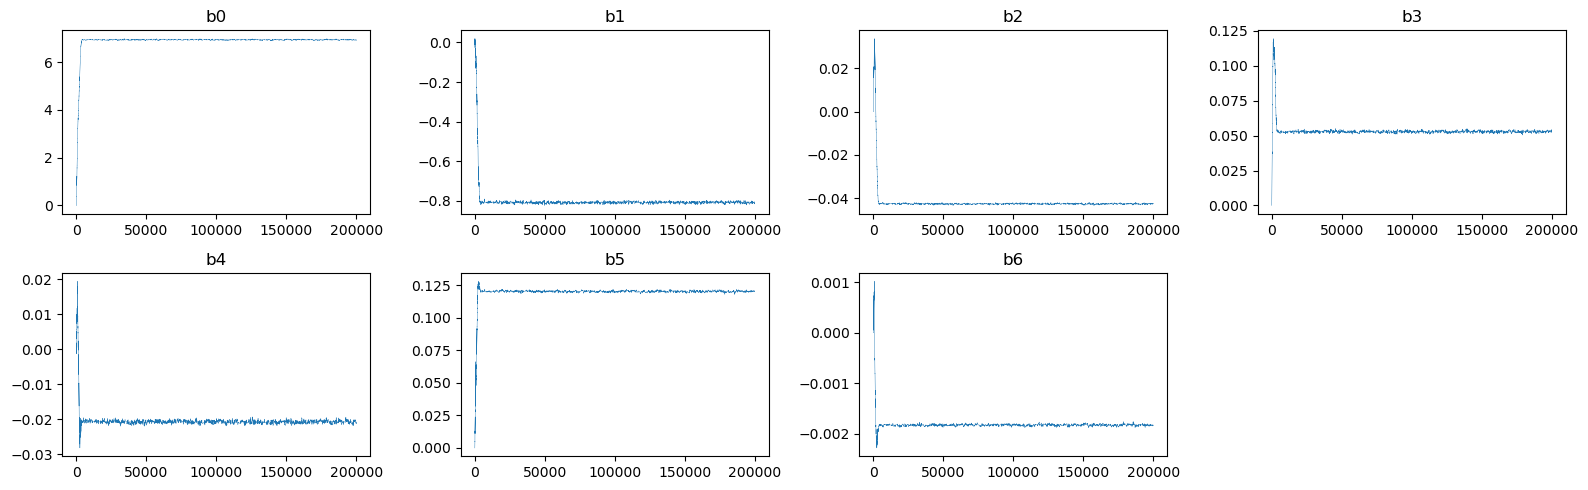

In [149]:
col_names = [f'b{j}' for j in range(p_dim)]
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for j in range(p_dim):
    axes.flat[j].plot(path_rw[:, j], linewidth=0.3)
    axes.flat[j].set_title(col_names[j])
axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()


It seems that the chain mixes well after a few initial iterations, which can be handled using burnin. 

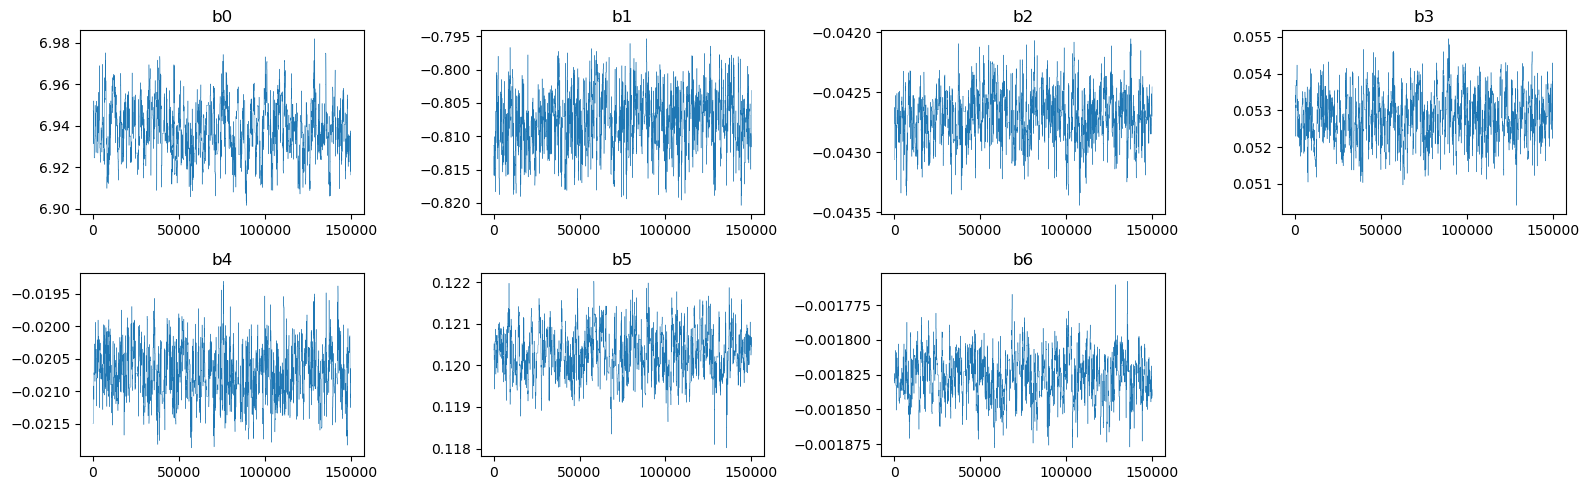

In [150]:
burnin = 50000
samples = path_rw[burnin:, :]
col_names = [f'b{j}' for j in range(p_dim)]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for j in range(p_dim):
    axes.flat[j].plot(samples[:, j], linewidth=0.3)
    axes.flat[j].set_title(col_names[j])
axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()


The posterior means and standard deviations are given below. 

In [151]:


print("Parameter | Estimate | Std. Dev. | Frequentist | Std. Error")
print("----------|----------|-----------|-------------|----------")
for j in range(p_dim):
    print(f"{col_names[j]:8}| {samples[:, j].mean():.6f} | {samples[:, j].std():.6f}  | {poiregmodel.params.values[j]:.6f}  | {poiregmodel.bse.values[j]:.6f}")



Parameter | Estimate | Std. Dev. | Frequentist | Std. Error
----------|----------|-----------|-------------|----------
b0      | 6.938211 | 0.012637  | 6.936480  | 0.012336
b1      | -0.807783 | 0.004127  | -0.807524  | 0.004179
b2      | -0.042709 | 0.000207  | -0.042680  | 0.000212
b3      | 0.052826 | 0.000657  | 0.052831  | 0.000633
b4      | -0.020707 | 0.000395  | -0.020714  | 0.000380
b5      | 0.120289 | 0.000534  | 0.120372  | 0.000549
b6      | -0.001826 | 0.000016  | -0.001829  | 0.000016


The output again is very similar to the posterior normal approximation. 

Finally, another choice of the proposal distribution is the so-called Independence Sampler where we take $y \sim N(\hat{\beta}, \rho * \Sigma)$ where $\hat{\beta}$ is the frequentist MLE, and $\Sigma$ is the covariance matrix of the Laplace posterior normal approximation, and $\rho$ is a constant slightly larger than 1. This proposal density does not depend on $x$ (the current state) which is why the resulting Metropolis-Hastings scheme is called the Independence sampler. Note that this proposal is not symmetric in $x$ and $y$ so the full acceptance probability $\min(1, \pi(y) P(y, x)/(\pi(x) P(x, y)))$ needs to be used. 

In [ ]:
nit = 100000
path_ind = np.zeros((nit, p_dim))

state = beta_hat.copy()
#state = np.zeros(p_dim) #with this initialization, the chain does not move at all!
path_ind[0, :] = state

rej_ind = 0
rho = 1.2  # scaling factor for the proposal covariance

for it in range(1, nit):
    # Propose from N(beta_hat, rho * cov_mat) -- centred at the MLE
    cand = multivariate_normal.rvs(mean=beta_hat, cov=rho * cov_mat)

    # Log acceptance ratio = log[ p(cand)/p(state) * q(state)/q(cand) ]
    log_ratio1 = logpost(cand) - logpost(state)
    log_ratio2 = (multivariate_normal.logpdf(state, mean=beta_hat, cov=rho * cov_mat)
                - multivariate_normal.logpdf(cand,  mean=beta_hat, cov=rho * cov_mat))
    log_ratio = log_ratio1 + log_ratio2

    rnum = np.random.uniform()
    if rnum < np.exp(min(0.0, log_ratio)):
        state = cand
    else:
        rej_ind += 1

    path_ind[it, :] = state

    if (it + 1) % 20000 == 0:
        print(f"Iteration {it + 1}")

print(f"\nIndependence sampler rejection rate: {rej_ind / nit:.4f}")


Iteration 20000
Iteration 40000
Iteration 60000
Iteration 80000
Iteration 100000

Independence sampler rejection rate: 0.1852


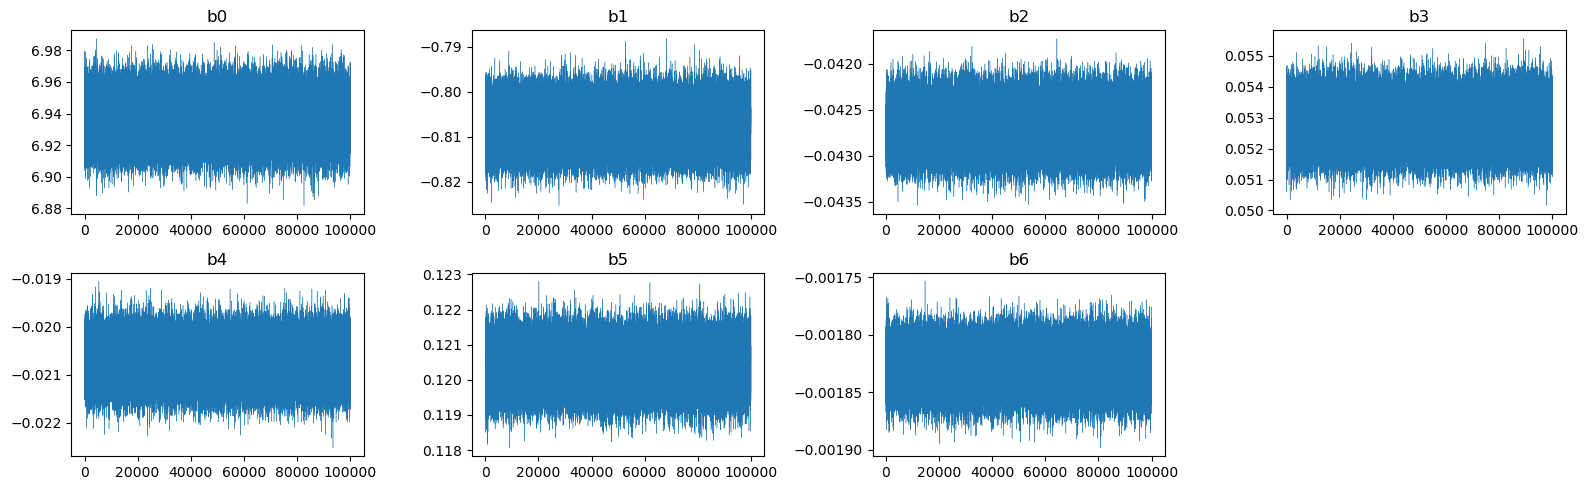

In [157]:
col_names = [f'b{j}' for j in range(p_dim)]
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for j in range(p_dim):
    axes.flat[j].plot(path_ind[:, j], linewidth=0.3)
    axes.flat[j].set_title(col_names[j])
axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()


This sampler is mixing very well. If the initial state is say zero, then this chain does not seem to move, so it is crucial to initialize this at the MLE. 

In [158]:


print("Parameter | Estimate | Std. Dev. | Frequentist | Std. Error")
print("----------|----------|-----------|-------------|----------")
for j in range(p_dim):
    print(f"{col_names[j]:8}| {path_ind[:, j].mean():.6f} | {path_ind[:, j].std():.6f}  | {poiregmodel.params.values[j]:.6f}  | {poiregmodel.bse.values[j]:.6f}")



Parameter | Estimate | Std. Dev. | Frequentist | Std. Error
----------|----------|-----------|-------------|----------
b0      | 6.936539 | 0.012378  | 6.936480  | 0.012336
b1      | -0.807521 | 0.004163  | -0.807524  | 0.004179
b2      | -0.042682 | 0.000213  | -0.042680  | 0.000212
b3      | 0.052829 | 0.000633  | 0.052831  | 0.000633
b4      | -0.020715 | 0.000381  | -0.020714  | 0.000380
b5      | 0.120375 | 0.000551  | 0.120372  | 0.000549
b6      | -0.001829 | 0.000016  | -0.001829  | 0.000016


The posterior means and standard deviations nearly coincide with the posterior normal approximation. 

The overall message is that in problems such as these, the posterior normal approximation is crucial. Using it, it is possible to design simple Metropolis-Hastings schemes that work. PyMC seems to give strange results on some occasions. 